In [2]:
# =========================================================
# 08_TIME_SERIES_FORECASTING.IPYNB
# =========================================================

# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

In [3]:
# =========================================================
# STEP 2 — LOAD DATA
# =========================================================

orders = pd.read_csv(r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\raw\orders.csv')

print(orders.shape)

orders.head()

(1000000, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20
1,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44
2,11bdf634-2b87-4d37-8d76-be1e7aff8f3b,89b0d980-868f-478d-a63b-5fea5f265f4f,delivered,2023-04-02 14:39:33,2023-04-02 23:42:33,2023-04-03 23:42:33,2023-04-08 23:42:33,2023-04-10 23:42:33
3,d29b58ad-af2a-47b4-9214-b2664fb1fdba,336d14e6-a22f-4126-b2b7-fa64a2955b34,delivered,2023-01-28 12:09:24,2023-01-28 15:26:24,2023-01-29 15:26:24,2023-02-02 15:26:24,2023-02-04 15:26:24
4,53fabbc8-fd4f-4c12-8af9-258db94dda6c,340c9f9d-bb72-4bfa-a6aa-aa9c7c18a03f,canceled,2019-06-05 22:33:47,2019-06-06 01:24:47,NaN,NaN,2019-06-16 01:24:47


In [4]:
# =========================================================
# STEP 3 — DATA UNDERSTANDING
# =========================================================

orders.info()

orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                         Non-Null Count    Dtype 
---  ------                         --------------    ----- 
 0   order_id                       1000000 non-null  object
 1   customer_id                    1000000 non-null  object
 2   order_status                   1000000 non-null  object
 3   order_purchase_timestamp       1000000 non-null  object
 4   order_approved_at              1000000 non-null  object
 5   order_delivered_carrier_date   933748 non-null   object
 6   order_delivered_customer_date  933748 non-null   object
 7   order_estimated_delivery_date  1000000 non-null  object
dtypes: object(8)
memory usage: 61.0+ MB


order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                    0
order_delivered_carrier_date     66252
order_delivered_customer_date    66252
order_estimated_delivery_date        0
dtype: int64

In [5]:
# =========================================================
# STEP 4 — CONVERT DATE COLUMN
# =========================================================

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [6]:
# =========================================================
# STEP 5 — EXTRACT REQUIRED COLUMNS
# =========================================================

ts_df = orders[[
    'order_id',
    'order_purchase_timestamp'
]]

ts_df.head()

,order_id,order_purchase_timestamp
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,2025-12-27 07:07:20
1,c0142972-63fa-4af2-8070-f583ab769847,2019-06-07 19:30:44
2,11bdf634-2b87-4d37-8d76-be1e7aff8f3b,2023-04-02 14:39:33
3,d29b58ad-af2a-47b4-9214-b2664fb1fdba,2023-01-28 12:09:24
4,53fabbc8-fd4f-4c12-8af9-258db94dda6c,2019-06-05 22:33:47


In [7]:
# =========================================================
# STEP 6 — CREATE DAILY ORDER COUNT
# =========================================================

daily_orders = (
    ts_df
    .groupby(
        ts_df['order_purchase_timestamp'].dt.date
    )
    .count()['order_id']
    .reset_index()
)

daily_orders.columns = ['Date', 'Order_Count']

daily_orders.head()

,Date,Order_Count
0,2019-01-01,133
1,2019-01-02,119
2,2019-01-03,139
3,2019-01-04,239
4,2019-01-05,298


In [8]:
# =========================================================
# STEP 7 — CONVERT DATE FORMAT
# =========================================================

daily_orders['Date'] = pd.to_datetime(
    daily_orders['Date']
)

daily_orders = daily_orders.sort_values('Date')

daily_orders.set_index('Date', inplace=True)

daily_orders.head()

,Order_Count
Date,
2019-01-01,133
2019-01-02,119
2019-01-03,139
2019-01-04,239
2019-01-05,298


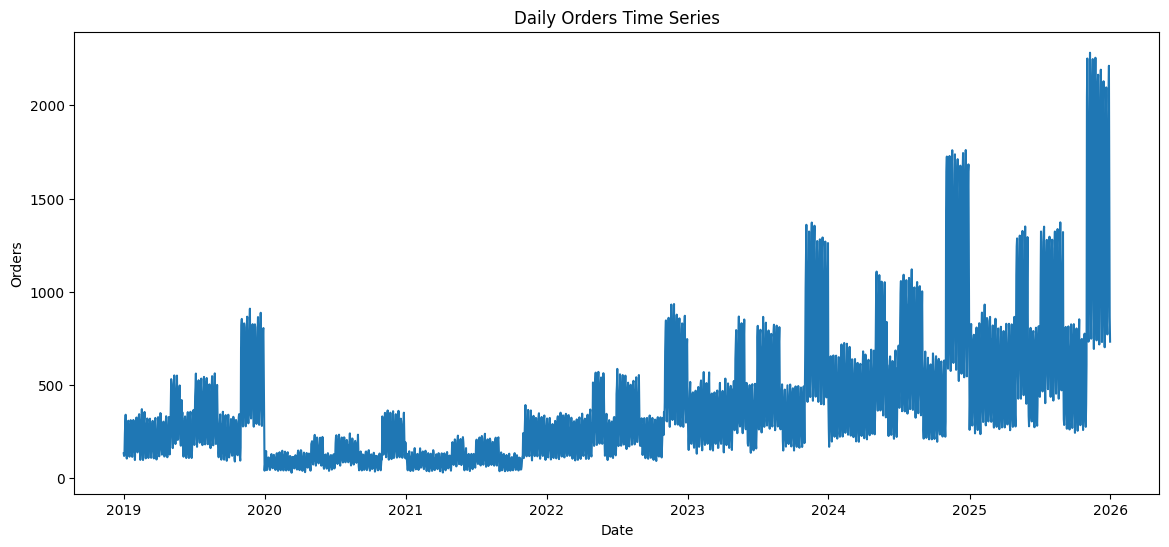

In [9]:
# =========================================================
# STEP 8 — VISUALIZE TIME SERIES
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    daily_orders.index,
    daily_orders['Order_Count']
)

plt.title("Daily Orders Time Series")

plt.xlabel("Date")

plt.ylabel("Orders")

plt.show()

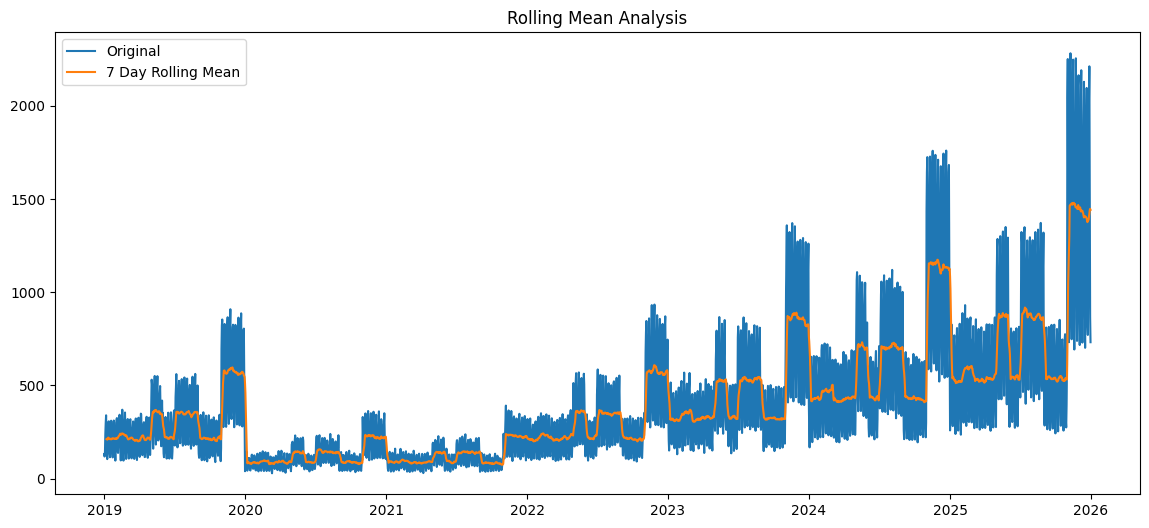

In [10]:
# =========================================================
# STEP 9 — ROLLING MEAN
# =========================================================

daily_orders['Rolling_Mean_7'] = (
    daily_orders['Order_Count']
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_orders['Order_Count'],
    label='Original'
)

plt.plot(
    daily_orders['Rolling_Mean_7'],
    label='7 Day Rolling Mean'
)

plt.legend()

plt.title("Rolling Mean Analysis")

plt.show()

In [11]:
# =========================================================
# STEP 10 — CHECK STATIONARITY
# =========================================================

result = adfuller(
    daily_orders['Order_Count']
)

print("ADF Statistic:", result[0])

print("p-value:", result[1])

# =========================================================
# INTERPRETATION
# =========================================================

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")


ADF Statistic: -2.5815568195510834
p-value: 0.09686932385638575
Data is Non-Stationary


In [12]:
# =========================================================
# STEP 11 — TRAIN TEST SPLIT
# =========================================================

train_size = int(len(daily_orders) * 0.8)

train = daily_orders.iloc[:train_size]

test = daily_orders.iloc[train_size:]

print(train.shape)

print(test.shape)

(2044, 2)
(511, 2)


In [13]:
# =========================================================
# STEP 12 — ARIMA MODEL
# =========================================================

arima_model = SARIMAX(
    train['Order_Count'],
    order=(5,1,2),
    seasonal_order=(1,1,1,7)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         Order_Count   No. Observations:                 2044
Model:             SARIMAX(5, 1, 2)x(1, 1, [1], 7)   Log Likelihood              -10700.954
Date:                             Wed, 13 May 2026   AIC                          21421.907
Time:                                     17:53:51   BIC                          21478.095
Sample:                                          0   HQIC                         21442.519
                                            - 2044                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8231      0.051     16.238      0.000       0.724       0.923
ar.L2         -0.5969      

In [14]:
# =========================================================
# STEP 13 — ARIMA FORECAST
# =========================================================

arima_preds = arima_result.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    dynamic=False
)

arima_preds.head()


2044     544.816965
2045     888.680609
2046    1037.646731
2047    1089.249042
2048     754.513727
Name: predicted_mean, dtype: float64

In [15]:
# =========================================================
# STEP 14 — EVALUATE ARIMA
# =========================================================

mae = mean_absolute_error(
    test['Order_Count'],
    arima_preds
)

rmse = np.sqrt(
    mean_squared_error(
        test['Order_Count'],
        arima_preds
    )
)

print("="*50)
print("ARIMA PERFORMANCE")
print("="*50)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")


ARIMA PERFORMANCE
MAE  : 586.72
RMSE : 669.15


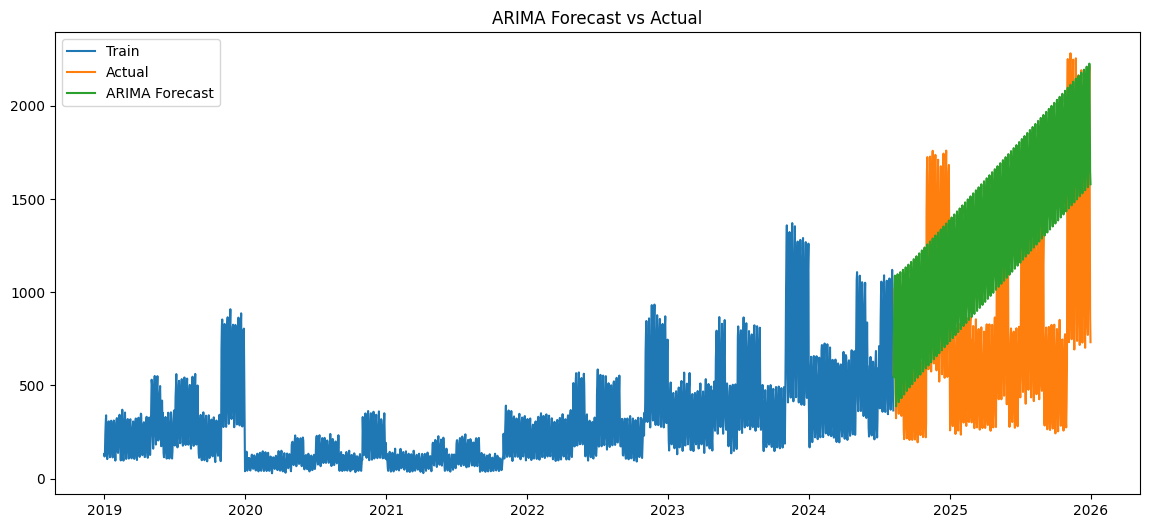

In [16]:
# =========================================================
# STEP 15 — VISUALIZE ARIMA FORECAST
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train['Order_Count'],
    label='Train'
)

plt.plot(
    test.index,
    test['Order_Count'],
    label='Actual'
)

plt.plot(
    test.index,
    arima_preds,
    label='ARIMA Forecast'
)

plt.legend()

plt.title("ARIMA Forecast vs Actual")

plt.show()

In [18]:
# =========================================================
# STEP 16 — PREPARE DATA FOR PROPHET
# =========================================================

prophet_df = (
    daily_orders
    .reset_index()[['Date', 'Order_Count']]
)

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2019-01-01,133
1,2019-01-02,119
2,2019-01-03,139
3,2019-01-04,239
4,2019-01-05,298


In [19]:
# =========================================================
# STEP 17 — TRAIN TEST SPLIT FOR PROPHET
# =========================================================

prophet_train_size = int(len(prophet_df) * 0.8)

prophet_train = prophet_df.iloc[:prophet_train_size]

prophet_test = prophet_df.iloc[prophet_train_size:]

# =========================================================
# STEP 18 — TRAIN PROPHET MODEL
# =========================================================

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

17:57:43 - cmdstanpy - INFO - Chain [1] start processing
17:57:45 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
# =========================================================
# STEP 19 — FUTURE DATAFRAME
# =========================================================

future = prophet_model.make_future_dataframe(
    periods=len(prophet_test)
)

forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-01-01,166.577487,100.236856,348.644037,166.577487,166.577487,63.888393,63.888393,63.888393,134.994846,...,-117.130874,-117.130874,-117.130874,46.024422,46.024422,46.024422,0.0,0.0,0.0,230.465881
1,2019-01-02,166.571031,60.183450,307.239887,166.571031,166.571031,17.438313,17.438313,17.438313,134.994846,...,-147.429287,-147.429287,-147.429287,29.872755,29.872755,29.872755,0.0,0.0,0.0,184.009344
2,2019-01-03,166.564575,110.229567,366.642981,166.564575,166.564575,77.619598,77.619598,77.619598,134.994846,...,-71.531934,-71.531934,-71.531934,14.156687,14.156687,14.156687,0.0,0.0,0.0,244.184173
3,2019-01-04,166.558118,241.708907,492.873188,166.558118,166.558118,196.761244,196.761244,196.761244,134.994846,...,62.708384,62.708384,62.708384,-0.941986,-0.941986,-0.941986,0.0,0.0,0.0,363.319362
4,2019-01-05,166.551662,285.649463,538.832736,166.551662,166.551662,240.115847,240.115847,240.115847,134.994846,...,120.377198,120.377198,120.377198,-15.256198,-15.256198,-15.256198,0.0,0.0,0.0,406.667509


In [21]:

# =========================================================
# STEP 20 — EXTRACT TEST FORECAST
# =========================================================

prophet_preds = forecast.iloc[-len(prophet_test):]


In [22]:
# =========================================================
# STEP 21 — EVALUATE PROPHET
# =========================================================

prophet_mae = mean_absolute_error(
    prophet_test['y'],
    prophet_preds['yhat']
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test['y'],
        prophet_preds['yhat']
    )
)

print("="*50)
print("PROPHET PERFORMANCE")
print("="*50)

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")

PROPHET PERFORMANCE
MAE  : 215.76
RMSE : 302.13


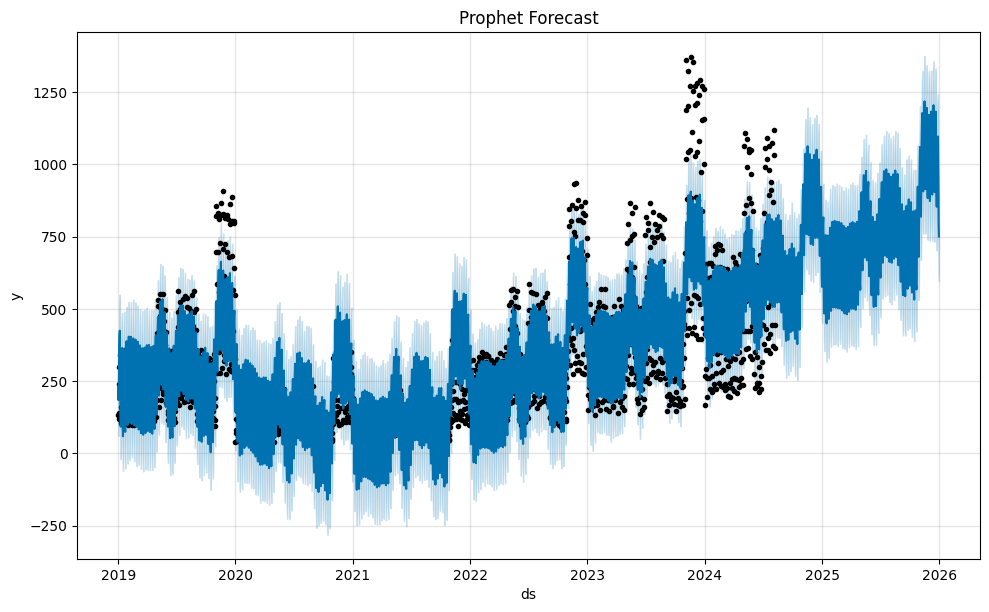

In [23]:
# =========================================================
# STEP 22 — VISUALIZE PROPHET FORECAST
# =========================================================

fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

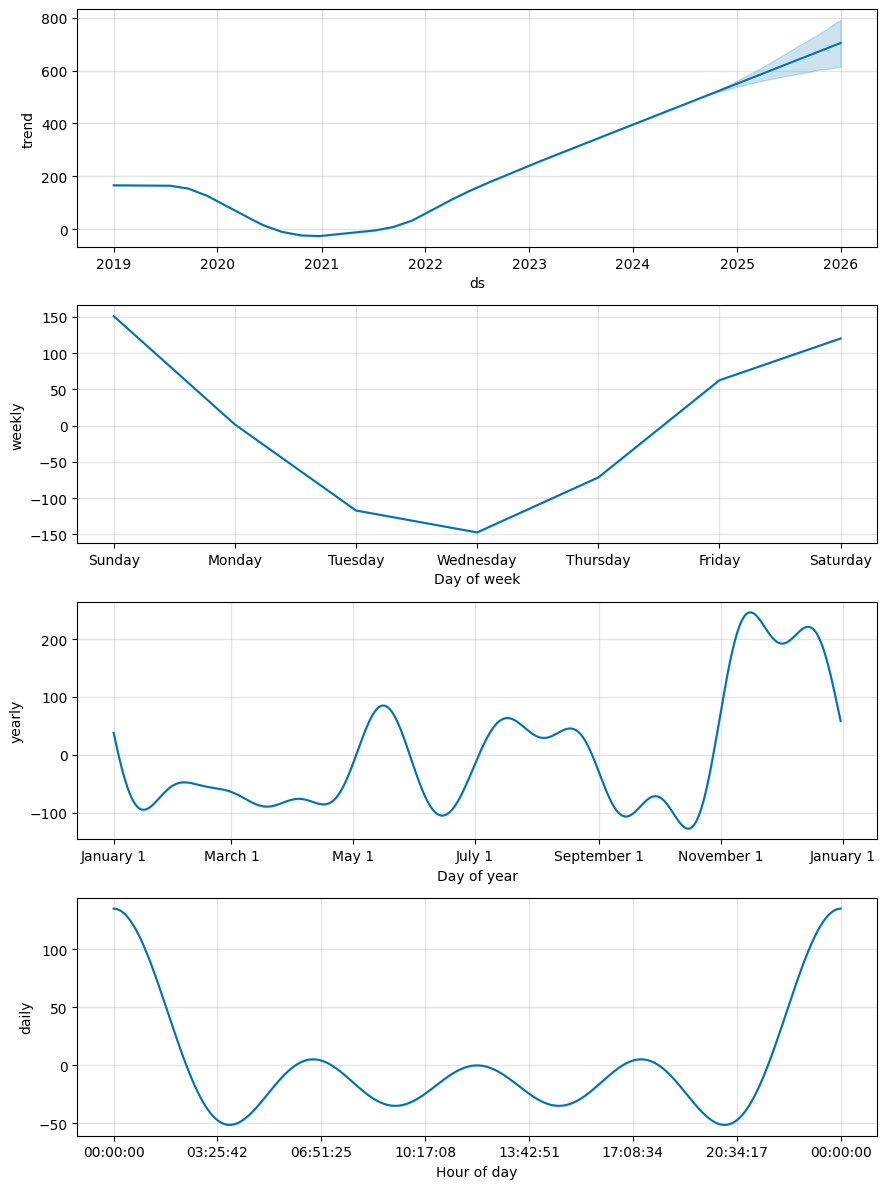

In [24]:
# =========================================================
# STEP 23 — PROPHET COMPONENTS
# =========================================================

fig2 = prophet_model.plot_components(
    forecast
)

plt.show()

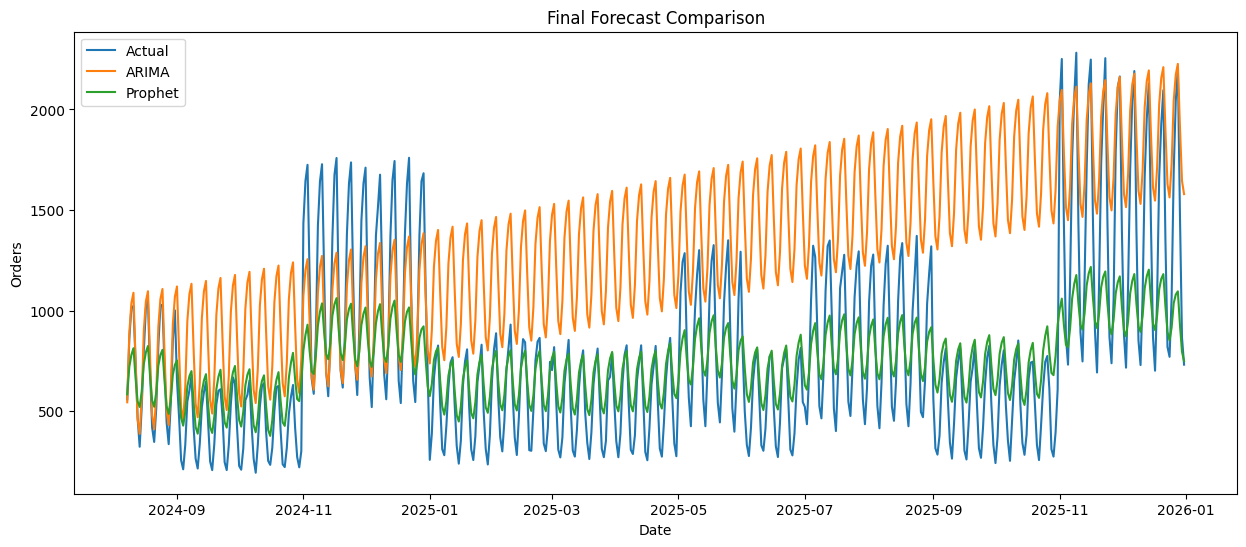

In [25]:
# =========================================================
# STEP 24 — FINAL COMPARISON PLOT
# =========================================================

plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test['Order_Count'],
    label='Actual'
)

plt.plot(
    test.index,
    arima_preds.values,
    label='ARIMA'
)

plt.plot(
    prophet_test['ds'],
    prophet_preds['yhat'],
    label='Prophet'
)

plt.title("Final Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Orders")

plt.legend()

plt.show()

In [26]:
# =========================================================
# STEP 25 — FUTURE FORECASTING
# =========================================================

future_30 = prophet_model.make_future_dataframe(
    periods=30
)

future_forecast = prophet_model.predict(
    future_30
)

future_forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
2069,2024-09-02,499.281528,476.587342,716.461528,499.087658,499.472785,95.485779,95.485779,95.485779,134.994846,...,1.728317,1.728317,1.728317,-41.237384,-41.237384,-41.237384,0.0,0.0,0.0,594.767307
2070,2024-09-03,499.703839,338.014287,594.306554,499.490195,499.918292,-32.294199,-32.294199,-32.294199,134.994846,...,-117.130874,-117.130874,-117.130874,-50.158171,-50.158171,-50.158171,0.0,0.0,0.0,467.409640
2071,2024-09-04,500.126149,296.807403,549.638412,499.885884,500.362409,-71.245648,-71.245648,-71.245648,134.994846,...,-147.429287,-147.429287,-147.429287,-58.811206,-58.811206,-58.811206,0.0,0.0,0.0,428.880502
2072,2024-09-05,500.548460,370.489196,627.006208,500.259415,500.810184,-3.596032,-3.596032,-3.596032,134.994846,...,-71.531934,-71.531934,-71.531934,-67.058944,-67.058944,-67.058944,0.0,0.0,0.0,496.952428
2073,2024-09-06,500.970771,495.677368,751.427258,500.624725,501.283385,122.931698,122.931698,122.931698,134.994846,...,62.708384,62.708384,62.708384,-74.771532,-74.771532,-74.771532,0.0,0.0,0.0,623.902469


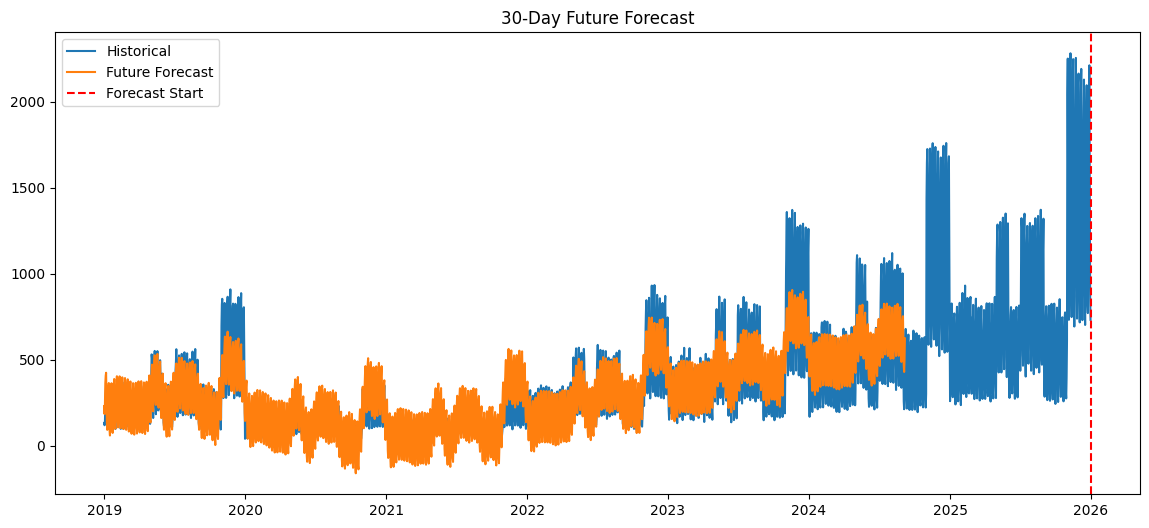

In [27]:
# =========================================================
# STEP 26 — VISUALIZE FUTURE FORECAST
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    prophet_df['ds'],
    prophet_df['y'],
    label='Historical'
)

plt.plot(
    future_forecast['ds'],
    future_forecast['yhat'],
    label='Future Forecast'
)

plt.axvline(
    prophet_df['ds'].max(),
    color='red',
    linestyle='--',
    label='Forecast Start'
)

plt.legend()

plt.title("30-Day Future Forecast")

plt.show()


In [ ]:
# =========================================================
# STEP 27 — SAVE FORECASTS
# =========================================================

future_forecast.to_csv(
    FORECAST_DIR / "forecast_results.csv",
    index=False
)

print("Forecast Results Saved Successfully")

Forecast Results Saved Successfully


In [29]:
# =========================================================
# STEP 28 — BUSINESS INSIGHTS
# =========================================================

print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("""
1. Daily order trends analyzed successfully.

2. Weekly seasonality detected in customer purchases.

3. Prophet captured long-term trend and seasonality effectively.

4. Forecasting can help:
   - Inventory Planning
   - Demand Forecasting
   - Warehouse Optimization
   - Seller Management
   - Marketing Campaign Planning

5. Future forecasts provide proactive decision-making support.
""")


BUSINESS INSIGHTS

1. Daily order trends analyzed successfully.

2. Weekly seasonality detected in customer purchases.

3. Prophet captured long-term trend and seasonality effectively.

4. Forecasting can help:
   - Inventory Planning
   - Demand Forecasting
   - Warehouse Optimization
   - Seller Management
   - Marketing Campaign Planning

5. Future forecasts provide proactive decision-making support.

